In [8]:
# import
import pandas as pd
import seaborn as sns

In [9]:
# load raw data into df
raw = pd.read_csv("/work/E2026/psycholing_kma/data/combined_data.csv")
raw.head()

,participant_id,component_num,url,meta,sender,sender_type,sender_id,ended_on,duration,time_run,...,response,response_action,prime,target,condition,soa_condition,congruence,correct_response,correctResponse,correct
0,51,1,NaN,NaN,Wecome1,canvas.Screen,1,timeout,499.56,3556.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,51,1,NaN,NaN,Wecome2,canvas.Screen,2,timeout,499.52,4056.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51,1,NaN,NaN,Wecome3,canvas.Screen,3,timeout,499.52,4555.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,51,1,NaN,NaN,Instructions1,canvas.Screen,4,response,9061.10,5061.0,...,NaN,keypress,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,51,1,NaN,NaN,Instructions 1a,canvas.Screen,5,response,2279.00,14148.0,...,NaN,keypress,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# get list of column names for ease
list(raw)

['participant_id',
 'component_num',
 'url',
 'meta',
 'sender',
 'sender_type',
 'sender_id',
 'ended_on',
 'duration',
 'time_run',
 'time_render',
 'time_show',
 'time_end',
 'time_commit',
 'timestamp',
 'time_switch',
 'response',
 'response_action',
 'prime',
 'target',
 'condition',
 'soa_condition',
 'congruence',
 'correct_response',
 'correctResponse',
 'correct']

In [11]:
# make list of relevant columns
cols = ["participant_id", "sender", "duration", "prime", "target", "condition", "soa_condition", "congruence", "response", "correct_response"]
cols

['participant_id',
 'sender',
 'duration',
 'prime',
 'target',
 'condition',
 'soa_condition',
 'congruence',
 'response',
 'correct_response']

In [15]:
# make new df with only relevant columns
df = raw[cols]
# keep only target rows i.e. filter out welcome screens etc
df = df[df["sender"] == "target"]
# drop now-irrelevant sender column
df = df.drop(columns = ['sender'])
# filter out practice rows
df = df[df["condition"] != "practice"]
# fix mistake that coded BULL as man-made
df.loc[df["target"] == "BULL", "correct_response"] = "n"
# make new column with 1 if response=correct response and 0 if not        
df["correct"] = (df["response"] == df["correct_response"]).astype(int)
# keep only rows with correct responses
df = df[df["correct"] == 1]
# rename soa and duration columns for looks                                          
df = df.rename(columns={"soa_condition": "soa", "duration": "rt"})
df.head()

,participant_id,rt,prime,target,condition,soa,congruence,response,correct_response,correct
40,51,520.14,roof,PIANO,Inc_Synth_Synth,long,incongruent,m,m,1
47,51,640.66,sheep,BULL,Inc_Nat_Nat,long,incongruent,n,n,1
54,51,597.74,fort,GOAT,Inc_Synth_Nat,long,incongruent,n,n,1
61,51,495.68,pear,PEAR,Con_Nat,long,congruent,n,n,1
68,51,556.86,olive,MOTOR,Inc_Nat_Synth,long,incongruent,m,m,1


In [20]:
# find avg values for conditions
df_grouped = df.groupby(['participant_id', 'soa', 'congruence'])['rt'].mean().reset_index()
df_grouped.head()

,participant_id,soa,congruence,rt
0,51,long,congruent,608.506207
1,51,long,incongruent,626.316522
2,51,short,congruent,559.113793
3,51,short,incongruent,617.301538
4,52,long,congruent,710.956667


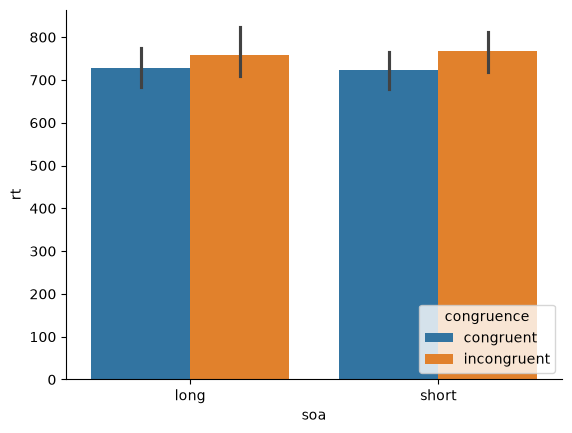

In [30]:
# make barplot
ax = sns.barplot(data = df_grouped, x = "soa", y = "rt", hue = "congruence")
# get rid of lines around top and right side
sns.despine(ax = ax) 
# move legend out of the way
sns.move_legend(ax, "lower right")